#  **Feature Selection Using RFECV and Random Forest**
This notebook performs recursive feature elimination with cross-validation (RFECV) using a Random Forest regressor to identify and retain the most informative molecular descriptors for pIC₅₀ prediction against Alzheimer's disease targets.

Key Steps:
1. Data Loading:

  - Imports previously filtered training and testing datasets (*_filtered_1.csv) that include RDKit descriptors and Morgan fingerprints, along with metadata (molecule_chembl_id, canonical_smiles, activity_class, pIC50).

2. RFECV-Based Feature Selection:

  - Applies RFECV with a RandomForestRegressor (5-fold cross-validation) to identify the optimal number of predictive features from the training set.

3. Selected features are retained using the support_ mask.

4. Saving REU-Selected Data:

  - The reduced training and testing datasets, containing only the selected features and metadata, are saved as *_reu.csv.

  - Blank or incomplete rows (containing NaNs) are explicitly removed to ensure clean datasets.

5. Visualization:

  - A performance plot of cross-validated R² scores vs. number of selected features is generated and saved.



In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFECV
from sklearn.model_selection import cross_validate
import matplotlib.pyplot as plt




In [ ]:
# === Configuration ===
meta_cols = ['molecule_chembl_id', 'canonical_smiles', 'activity_class', 'pIC50']
input_dir = "/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/descriptors/reduced_features_1/"
output_dir = "/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/descriptors/reduced_features_reu_2/"
os.makedirs(output_dir, exist_ok=True)

In [ ]:
# === Load Filtered Dataset and drop blank rows ===
train_file = os.path.join(input_dir, "gsk-3beta_feature_filtered_1_train.csv")
test_file = os.path.join(input_dir, "gsk-3beta_feature_filtered_1_test.csv")

train_df = pd.read_csv(train_file).dropna(how="all").reset_index(drop=True)
test_df = pd.read_csv(test_file).dropna(how="all").reset_index(drop=True)

X_train = train_df.drop(columns=meta_cols)
y_train = train_df["pIC50"]
X_test = test_df.drop(columns=meta_cols)
y_test = test_df["pIC50"]


In [ ]:
# Check for NaN values in target
print("Number of NaNs in y_train:", train_df.isna().sum())

# View the rows with NaN in target
if y_train.isna().sum() > 0:
    print("\nRows with NaN in target:")
    display(train_df[train_df["pIC50"].isna()])

Number of NaNs in y_train: molecule_chembl_id       0
canonical_smiles         0
activity_class           0
pIC50                    0
rdk_MaxAbsEStateIndex    0
                        ..
fp_2038                  0
fp_2041                  0
fp_2044                  0
fp_2045                  0
fp_2047                  0
Length: 1004, dtype: int64


In [ ]:
X_train.head()

,rdk_MaxAbsEStateIndex,rdk_MinAbsEStateIndex,rdk_MinEStateIndex,rdk_qed,rdk_SPS,rdk_MolWt,rdk_FpDensityMorgan1,rdk_FpDensityMorgan2,rdk_FpDensityMorgan3,rdk_BCUT2D_MWHI,...,fp_2032,fp_2033,fp_2034,fp_2035,fp_2036,fp_2038,fp_2041,fp_2044,fp_2045,fp_2047
0,12.944934,0.262996,-0.262996,0.607352,11.083333,339.399,1.083333,1.875000,2.708333,32.133584,...,0,0,0,0,0,0,0,0,0,0
1,9.972560,0.145912,-1.173006,0.415446,11.464286,385.428,1.357143,2.142857,2.750000,16.564575,...,0,0,0,0,0,0,0,0,0,0
2,11.880680,0.076096,-0.411925,0.505792,22.473684,324.138,1.368421,2.157895,2.842105,79.918731,...,0,0,0,0,0,0,0,0,0,0
3,12.792804,0.212046,-0.369945,0.521468,10.100000,392.422,0.933333,1.733333,2.500000,16.149810,...,0,0,0,0,0,0,0,0,0,0
4,14.179599,0.231287,-0.481970,0.398420,14.029412,454.465,0.970588,1.882353,2.735294,19.142148,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
y_train.head()

,pIC50
0,6.872895
1,5.585027
2,8.000000
3,9.823909
4,6.508638


In [ ]:
# Check for NaN values in target
print("Number of NaNs in y_train:", y_train.isna().sum())

# View the rows with NaN in target
if y_train.isna().sum() > 0:
    print("\nRows with NaN in target:")
    display(train_df[train_df["pIC50"].isna()])


Number of NaNs in y_train: 0


In [ ]:
# === RFECV Feature Selection ===
print("Running RFECV...")
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rfecv = RFECV(estimator=rf, step=10, cv=5, scoring='r2', n_jobs=-1)
rfecv.fit(X_train, y_train)

selected_cols = X_train.columns[rfecv.support_]
print(f"RFECV selected {len(selected_cols)} features.")

Running RFECV...
RFECV selected 820 features.


In [ ]:
# === Save Reduced Train/Test Sets ===
X_train_reu = X_train[selected_cols].reset_index(drop=True)
X_test_reu = X_test[selected_cols].reset_index(drop=True)
meta_train = train_df[meta_cols].reset_index(drop=True)
meta_test = test_df[meta_cols].reset_index(drop=True)

train_reu_df = pd.concat([meta_train, X_train_reu], axis=1)
test_reu_df = pd.concat([meta_test, X_test_reu], axis=1)

train_out = os.path.join(output_dir, "gsk-3beta_train_reu.csv")
test_out = os.path.join(output_dir, "gsk-3beta_test_reu.csv")
train_reu_df.to_csv(train_out, index=False)
test_reu_df.to_csv(test_out, index=False)

print("Saved REU-selected datasets:")
print(f" - {train_out}\n - {test_out}")

Saved REU-selected datasets:
 - /content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/descriptors/reduced_features_reu_2/gsk-3beta_train_reu.csv
 - /content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/descriptors/reduced_features_reu_2/gsk-3beta_test_reu.csv


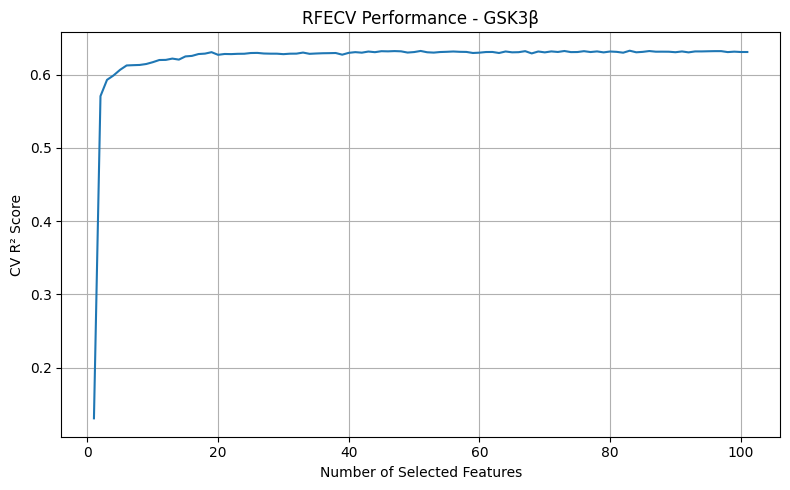

In [ ]:
# === Plot RFECV Performance ===
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(rfecv.cv_results_["mean_test_score"])+1), rfecv.cv_results_["mean_test_score"])
plt.xlabel("Number of Selected Features")
plt.ylabel("CV R² Score")
plt.title("RFECV Performance - GSK3β")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "gsk-3beta_rfecv_curve.png"))
plt.show()


In [ ]:
# Detect where performance plateaus (change in R² < 0.001)
scores = rfecv.cv_results_['mean_test_score']
plateau_n = None
for i in range(1, len(scores)):
    if abs(scores[i] - scores[i - 1]) < 0.001:
        plateau_n = i + 1  # since index starts at 0
        print(f" R² plateaus around {plateau_n} features → R² = {scores[i]:.4f}")
        break
if plateau_n is None:
    plateau_n = min(len(scores), 30)  # fallback default
    print(f"No plateau detected within tolerance. Using top {plateau_n} features.")

 R² plateaus around 7 features → R² = 0.6128


In [ ]:
# === Save Top-N Plateau-Based Train/Test Sets ===
top_indices = np.argsort(rfecv.ranking_)[:plateau_n]
topn_cols = X_train.columns[top_indices]

X_train_topn = X_train[topn_cols].reset_index(drop=True)
X_test_topn = X_test[topn_cols].reset_index(drop=True)

train_topn_df = pd.concat([meta_train, X_train_topn], axis=1)
test_topn_df = pd.concat([meta_test, X_test_topn], axis=1)

train_topn_out = os.path.join(output_dir, "gsk-3beta_train_reu_topN.csv")
test_topn_out = os.path.join(output_dir, "gsk-3beta_test_reu_topN.csv")
train_topn_df.to_csv(train_topn_out, index=False)
test_topn_df.to_csv(test_topn_out, index=False)

print(" Saved Top-N plateau-based RFECV datasets:")
print(f" - {train_topn_out}\n - {test_topn_out}")

 Saved Top-N plateau-based RFECV datasets:
 - /content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/descriptors/reduced_features_reu_2/gsk-3beta_train_reu_topN.csv
 - /content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/descriptors/reduced_features_reu_2/gsk-3beta_test_reu_topN.csv
